In [16]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [17]:
!pip3 install cv3

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\marku\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip


In [18]:
flat_chess = cv2.imread("1.png")

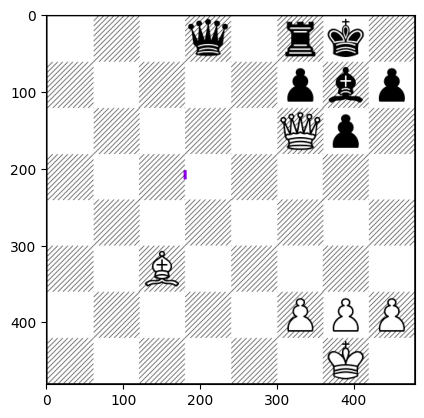

In [19]:


plt.imshow(flat_chess)



In [20]:
found, corners = cv2.findChessboardCorners(flat_chess, (7, 7))

found

False

In [21]:
cv2.drawChessboardCorners(flat_chess, (7, 7), corners, found)

array([[[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]],

       ...,

       [[  0,   0,   0],
        [  0,   0,   0],
        [255, 255, 255],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [226, 226, 226],
        ...,
        [255, 255, 255],
        [255, 255, 255],
        [  0,   0,   0]],

       [[  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0],
        ...,
        [  0,   0,   0],
        [  0,   0,   0],
        [  0,   0,   0]]

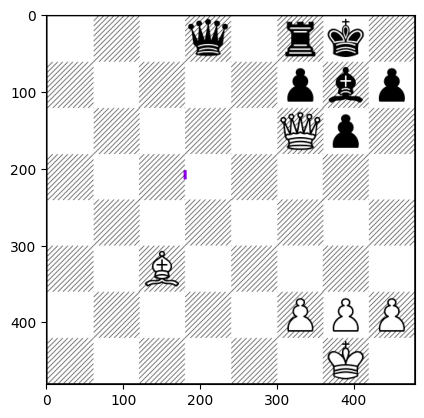

In [22]:
plt.imshow(flat_chess)

In [23]:
print(flat_chess)

[[[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]

 ...

 [[  0   0   0]
  [  0   0   0]
  [255 255 255]
  ...
  [255 255 255]
  [255 255 255]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [226 226 226]
  ...
  [255 255 255]
  [255 255 255]
  [  0   0   0]]

 [[  0   0   0]
  [  0   0   0]
  [  0   0   0]
  ...
  [  0   0   0]
  [  0   0   0]
  [  0   0   0]]]


In [26]:
import cv2
import numpy as np

img = cv2.imread("1.png")
gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

# Find board
edges = cv2.Canny(gray, 30, 100)
contours, _ = cv2.findContours(edges, cv2.RETR_TREE, cv2.CHAIN_APPROX_SIMPLE)

largest_contour = max(contours, key=cv2.contourArea)
x, y, w, h = cv2.boundingRect(largest_contour)

board = img[y:y+h, x:x+w]
board_gray = gray[y:y+h, x:x+w]

# Divide into 8x8
square_h = h // 8
square_w = w // 8

piece_board = []

for row in range(8):
    row_pieces = []
    for col in range(8):
        y1 = row * square_h
        x1 = col * square_w
        y2 = y1 + square_h
        x2 = x1 + square_w
        
        square = board[y1:y2, x1:x2]
        square_gray = board_gray[y1:y2, x1:x2]
        
        # Detect pieces by looking at the center area of square
        center_y1 = square_h // 4
        center_y2 = square_h * 3 // 4
        center_x1 = square_w // 4
        center_x2 = square_w * 3 // 4
        
        center = square_gray[center_y1:center_y2, center_x1:center_x2]
        
        mean_brightness = np.mean(center)
        std_dev = np.std(center)
        
        # Check if there's a piece (not uniform background)
        if std_dev > 20:
            # There's a piece - now determine color
            very_dark = center < 80  # Black piece fills
            dark_count = np.sum(very_dark)
            light_pixels = center > 200
            light_count = np.sum(light_pixels)
            
            total = center.shape[0] * center.shape[1]
            
            dark_ratio = dark_count / total
            light_ratio = light_count / total
            
            # Black pieces have solid dark areas
            if dark_ratio > 0.15:
                piece = "Black"
            # White pieces are outlined/hollow with white inside
            elif light_ratio > 0.3 and mean_brightness > 180:
                piece = "White"
            elif mean_brightness < 150:
                piece = "Black"
            else:
                piece = "White" if mean_brightness > 180 else "Black"
        else:
            piece = "Empty"
        
        row_pieces.append(piece)
    piece_board.append(row_pieces)

# Print board
print("\n=== CHESS BOARD ===\n")
print("  a b c d e f g h")

for row_num in range(8):
    print(f"{8-row_num} ", end="")
    for col_num in range(8):
        piece = piece_board[row_num][col_num]
        if piece == "White":
            print("♔ ", end="")
        elif piece == "Black":
            print("♚ ", end="")
        else:
            print("· ", end="")
    print(f" {8-row_num}")

print("  a b c d e f g h")

# Print detailed
print("\n=== DETAILED ===\n")
for row_num in range(8):
    row_display = []
    for piece in piece_board[row_num]:
        if piece == "White":
            row_display.append("W")
        elif piece == "Black":
            row_display.append("B")
        else:
            row_display.append(".")
    print(f"Rank {8-row_num}: {' '.join(row_display)}")


=== CHESS BOARD ===

  a b c d e f g h
8 · ♔ · ♚ · ♚ ♚ ♔  8
7 ♔ · ♔ · ♔ ♚ ♚ ♚  7
6 · ♔ · ♔ · ♚ ♚ ♔  6
5 ♔ · ♔ · ♔ · ♔ ·  5
4 · ♔ · ♔ · ♔ · ♔  4
3 ♔ · ♚ · ♔ · ♔ ·  3
2 · ♔ · ♔ · ♚ ♔ ♚  2
1 ♔ · ♔ · ♔ · ♚ ·  1
  a b c d e f g h

=== DETAILED ===

Rank 8: . W . B . B B W
Rank 7: W . W . W B B B
Rank 6: . W . W . B B W
Rank 5: W . W . W . W .
Rank 4: . W . W . W . W
Rank 3: W . B . W . W .
Rank 2: . W . W . B W B
Rank 1: W . W . W . B .


In [25]:
!pip3 install pytesseract

Defaulting to user installation because normal site-packages is not writeable



[notice] A new release of pip is available: 25.2 -> 26.0.1
[notice] To update, run: C:\Users\marku\AppData\Local\Microsoft\WindowsApps\PythonSoftwareFoundation.Python.3.13_qbz5n2kfra8p0\python.exe -m pip install --upgrade pip
